In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.Align import substitution_matrices
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import joblib
import os

In [6]:
mapped_scores =  pd.read_csv('data/mapped_scores.csv')

In [7]:
mapped_scores

,PDB_ResNum,Residue,Conservation_Score,Shannon_Entropy
0,1269,Q,0.951613,0.279506
1,1270,E,1.000000,0.000000
2,1271,V,1.000000,0.000000
3,1272,R,1.000000,0.000000
4,1273,L,0.790323,0.822901
...,...,...,...,...
1018,2302,A,1.000000,0.000000
1019,2303,D,1.000000,0.000000
1020,2304,Y,1.000000,0.000000
1021,2305,S,1.000000,0.000000


In [9]:
aa_props = {
    'A': {'charge': 0, 'hydrophobicity': 1.8, 'class': 'nonpolar'},
    'R': {'charge': 1, 'hydrophobicity': -4.5, 'class': 'basic'}, 
    'N': {'charge': 0, 'hydrophobicity': -3.5, 'class': 'polar'},
    'D': {'charge': -1, 'hydrophobicity': -3.5, 'class': 'acidic'},
    'C': {'charge': 0, 'hydrophobicity': 2.5, 'class': 'polar'},
    'Q': {'charge': 0, 'hydrophobicity': -3.5, 'class': 'polar'},
    'E': {'charge': -1, 'hydrophobicity': -3.5, 'class': 'acidic'},
    'G': {'charge': 0, 'hydrophobicity': -0.4, 'class': 'nonpolar'},
    'H': {'charge': 0, 'hydrophobicity': -3.2, 'class': 'polar'},
    'I': {'charge': 0, 'hydrophobicity': 4.5, 'class': 'nonpolar'},
    'L': {'charge': 0, 'hydrophobicity': 3.8, 'class': 'nonpolar'},
    'K': {'charge': 1, 'hydrophobicity': -3.9, 'class': 'basic'},
    'M': {'charge': 0, 'hydrophobicity': 1.9, 'class': 'nonpolar'},
    'F': {'charge': 0, 'hydrophobicity': 2.8, 'class': 'aromatic'},
    'P': {'charge': 0, 'hydrophobicity': -1.6, 'class': 'nonpolar'},
    'S': {'charge': 0, 'hydrophobicity': -0.8, 'class': 'polar'},
    'T': {'charge': 0, 'hydrophobicity': -0.7, 'class': 'polar'},
    'W': {'charge': 0, 'hydrophobicity': -0.9, 'class': 'aromatic'},
    'Y': {'charge': 0, 'hydrophobicity': -1.3, 'class': 'aromatic'},
    'V': {'charge': 0, 'hydrophobicity': 4.2, 'class': 'nonpolar'}
}

In [10]:
blosum62 = substitution_matrices.load("BLOSUM62")

In [11]:
def get_blosum_score(aa1, aa2):
    try:
        return blosum62[(aa1, aa2)]
    except:
        return 0

In [12]:
print(f"Test: A->K substitution score = {get_blosum_score('A', 'R')}")

Test: A->K substitution score = -1.0


In [13]:
amino_acids = list(aa_props.keys())
mutations = []
n_mutations = 2000

In [14]:
for i in range(n_mutations):
    # Pick random position from dataframe
    pos_idx = np.random.randint(0, len(mapped_scores))
    pos_data = mapped_scores.iloc[pos_idx]

    wildtype = pos_data['Residue']
    mutant = np.random.choice(amino_acids)

    if wildtype == mutant:
        continue

    # Get properties
    wt = aa_props[wildtype]
    mut = aa_props[mutant]

    mutation = {
        'conservation_score': pos_data['Conservation_Score'],
        'shannon_entropy': pos_data['Shannon_Entropy'],
        'blosum_score': get_blosum_score(wildtype, mutant),
        'charge_change': abs(mut['charge'] - wt['charge']),
        'hydrophobicity_change': abs(mut['hydrophobicity'] - wt['hydrophobicity']),
        'class_change': int(mut['class'] != wt['class'])
    }
    
    mutations.append(mutation)

In [15]:
mut_df = pd.DataFrame(mutations)

In [16]:
mut_df

,conservation_score,shannon_entropy,blosum_score,charge_change,hydrophobicity_change,class_change
0,1.0,0.0,1.0,0,2.6,1
1,1.0,0.0,-4.0,0,4.2,0
2,1.0,0.0,2.0,0,0.4,0
3,1.0,0.0,-2.0,0,7.3,1
4,1.0,0.0,-1.0,1,5.7,1
...,...,...,...,...,...,...
1887,1.0,0.0,0.0,0,2.8,0
1888,1.0,0.0,0.0,0,1.0,1
1889,1.0,0.0,-3.0,0,4.6,0
1890,1.0,0.0,-1.0,1,0.3,1


In [22]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(mut_df)

In [47]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(x_scaled)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [48]:
labels = gmm.predict(x_scaled)
probs = gmm.predict_proba(x_scaled).max(axis=1)

In [49]:
mut_df['cluster'] = labels
mut_df['confidence'] = probs

mean_blosum = mut_df.groupby('cluster')['blosum_score'].mean().sort_values()

cluster_names = {
    mean_blosum.index[0]: 'Disruptive',
    mean_blosum.index[1]: 'Moderate',
    mean_blosum.index[2]: 'Neutral'}

mut_df['cluster_label'] = mut_df['cluster'].map(cluster_names)

In [51]:
print(mut_df['cluster_label'].value_counts())

cluster_label
Neutral       1081
Disruptive     616
Moderate       195
Name: count, dtype: int64


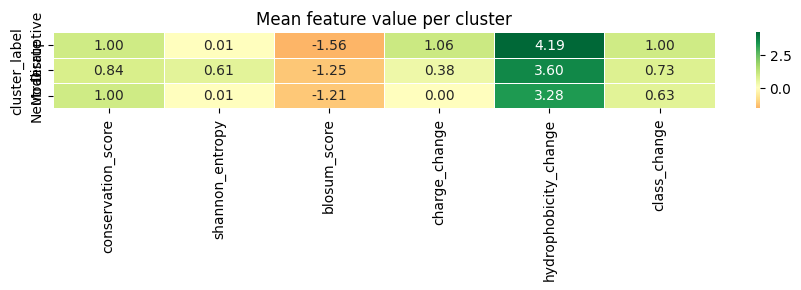

In [52]:
features = ['conservation_score', 'shannon_entropy', 'blosum_score',
            'charge_change', 'hydrophobicity_change', 'class_change']

cluster_means = mut_df.groupby('cluster_label')[features].mean()

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(
    cluster_means,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Mean feature value per cluster')
plt.tight_layout()
plt.show()

In [41]:
mut_df

,conservation_score,shannon_entropy,blosum_score,charge_change,hydrophobicity_change,class_change,cluster,confidence,cluster_label
0,1.0,0.0,1.0,0,2.6,1,0,1.0,Disruptive
1,1.0,0.0,-4.0,0,4.2,0,1,1.0,Neutral
2,1.0,0.0,2.0,0,0.4,0,1,1.0,Neutral
3,1.0,0.0,-2.0,0,7.3,1,0,1.0,Disruptive
4,1.0,0.0,-1.0,1,5.7,1,0,1.0,Disruptive
...,...,...,...,...,...,...,...,...,...
1887,1.0,0.0,0.0,0,2.8,0,1,1.0,Neutral
1888,1.0,0.0,0.0,0,1.0,1,0,1.0,Disruptive
1889,1.0,0.0,-3.0,0,4.6,0,1,1.0,Neutral
1890,1.0,0.0,-1.0,1,0.3,1,0,1.0,Disruptive


In [56]:
joblib.dump(gmm, 'models/gmm.pkl')
joblib.dump(scaler, 'models/scaler.pkl') 
joblib.dump(aa_props, 'models/aa_properties.pkl')
joblib.dump(cluster_names, 'models/cluster_names.pkl')

['models/cluster_names.pkl']